# Chapter 9: Signal Analysis (Spectrogram)

Daniel Koehn

Kiel, July 2nd 2026

Disclaimer: The Python code in this notebook was partially created by Google AI and modified by the author.

In [87]:
# Import Python libraries
import numpy as np
import matplotlib.pyplot as plt

Lets implement a function to compute the spectrogram for a time series, for serious applications the more efficient option would be to use the `SciPy` function [spectrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.ShortTimeFFT.spectrogram.html#scipy.signal.ShortTimeFFT.spectrogram) from the signal sub-library ...

In [88]:
def compute_spectrogram(time_series, fs, nperseg=256, noverlap=128):
    """
    Compute spectrogram of a time series using Short Time Fourier Transform (STFT).
    
    Parameters:
    time_series (array_like): input signals (1D-Array)
    fs (float): time domain sampling frequency [Hz]
    nperseg (int): length of window length
    noverlap (int): number of overlapping samples between the windows
    
    Output:
    frequencies (ndarray): frequency array
    times (ndarray): time array
    spectrogram (ndarray): 2D array of spectrogram
    """
    
    # 1. Parameter-Initilization
    step = nperseg - noverlap
    window = np.hanning(nperseg)  # Hanning-window to mitigate leak effects
    
    # Compute number of segments (time window)
    num_segments = (len(time_series) - noverlap) // step
    
    # Prepare output matrix
    num_freqs = nperseg // 2 + 1
    spectrogram = np.zeros((num_freqs, num_segments))

    # 2. Segmentation and FFT
    for i in range(num_segments):
        start = i * step
        end = start + nperseg
        segment = time_series[start:end] * window
        
        # Apply Fast Fourier Transformation (FFT)
        fft_result = np.fft.rfft(segment)
        
        # Compute power density (magnitude squared)
        spectrogram[:, i] = np.abs(fft_result)**2
        
    # 3. Compute axis scaling
    frequencies = np.fft.rfftfreq(nperseg, d=1/fs)
    times = np.arange(num_segments) * (step / fs) + (nperseg / (2 * fs))

    # 4. Compute amplitude spectrum of the whole time series
    n_samples = len(time_series)
    fft_global = np.fft.fft(time_series)                 # Compute FFT
    fft_global = np.abs(fft_global)                      # Compute amplitude spectrum
    freq_fft_global = np.fft.fftfreq(n_samples, 1 / fs)  # Compute frequencies of global FFT

    fft_global = np.fft.fftshift(fft_global)             # fftshift amplitude spectrum
    freq_fft_global = np.fft.fftshift(freq_fft_global)   # fftshift frequencies
    
    return frequencies, times, spectrogram, fft_global, freq_fft_global

Test spectrogram function using a simple time series

In [89]:
# Define parameters
nperseg = 100           # window length [samples]
noverlap = 25           # window overlap [samples] - should be always smaller than nperseg
dt = 1.                 # time sampling [s]
fs = 1 / dt             # sampling frequency [Hz]
L = 1000.               # length of the time series [s]

# Define time array
t = np.arange(0,L+dt,dt) # compute time vector
N = len(t)

#  Add spike impulses to time series ...
signal = np.zeros(N)
signal[N//2] = 10.

# ... and add two cosine functions with two different frequencies f1 and f2 [Hz]
f1 = 0.125
f2 = 0.05
omega1 = 2. * np.pi * f1      # compute circular frequency from f1
omega2 = 2. * np.pi * f2      # compute circular frequency from f2

s1 = np.cos(omega1*t)   # compute sine wave 1
s2 = np.cos(omega2*t)   # compute sine wave 2

signal += s1 + s2 

# Compute spectrogram
frequencies, times, spec, fft_global, freq_fft_global = compute_spectrogram(signal, fs, nperseg, noverlap)

# Convert to dezibel (dB) for a better visualization of the dynamic range
# add small offset to prevent logarithm error of zero
spec_db = 10 * np.log10(spec + 1e-10)

Lets create a fancy plot by combining the spectrogram with the original data series in the time domain and amplitude spectrum of the whole time series ...

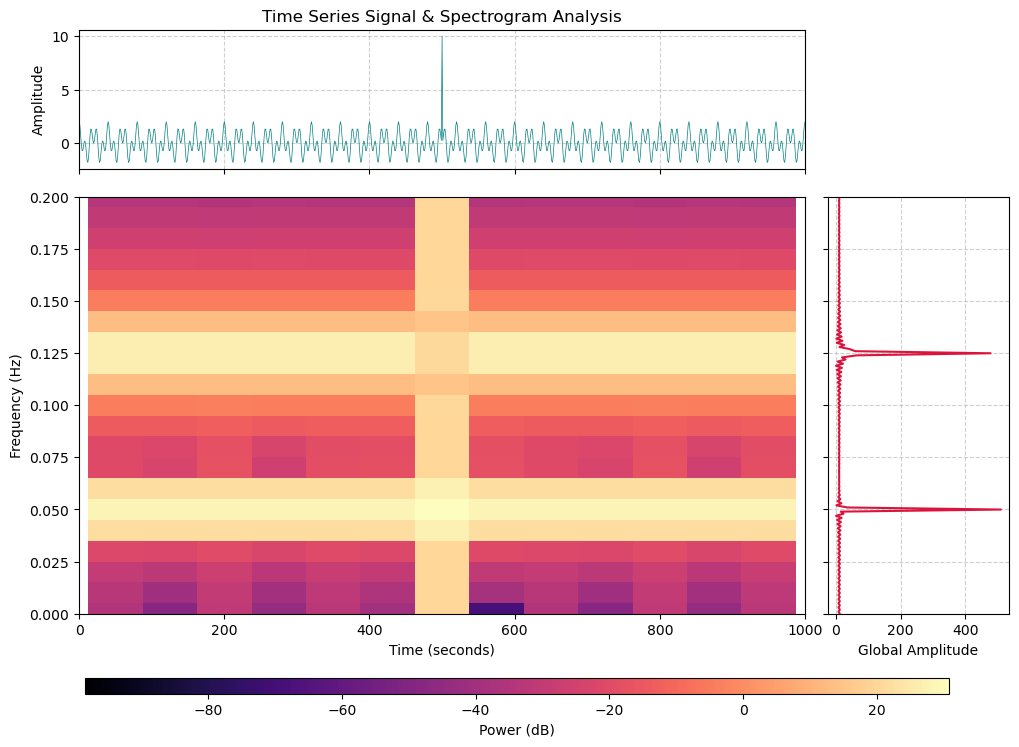

In [90]:
# 3. Create a unified plot with a shared grid layout
fig = plt.figure(figsize=(12, 8))
gs = fig.add_gridspec(2, 2, width_ratios=[4, 1], height_ratios=[1, 3])

# Subplot A: Original Time Series (Top-Left)
ax_time = fig.add_subplot(gs[0, 0])
ax_time.plot(t, signal, color="teal", lw=0.5)
ax_time.set_ylabel("Amplitude")
ax_time.set_xlim(t[0], t[-1])
ax_time.title.set_text("Time Series Signal & Spectrogram Analysis")
ax_time.grid(True, linestyle="--", alpha=0.6)

# Subplot B: Spectrogram (Bottom-Left)
ax_spec = fig.add_subplot(gs[1, 0], sharex=ax_time)

# Use pcolormesh to plot frequencies over time (log scale for intensity)
pcm = ax_spec.pcolormesh(
    times,
    frequencies,
    spec_db, 
    cmap="magma",
)
ax_spec.set_xlabel("Time (seconds)")
ax_spec.set_ylabel("Frequency (Hz)")
ax_spec.set_ylim(0, 0.2)  # Limit spectrum to 0.2 Hz

# Subplot C: Average Amplitude Spectrum (Bottom-Right)
ax_amp = fig.add_subplot(gs[1, 1], sharey=ax_spec)
ax_amp.plot(fft_global, freq_fft_global, color="crimson", lw=1.5)
ax_amp.set_xlabel("Global Amplitude")
ax_amp.grid(True, linestyle="--", alpha=0.6)

# Remove redundant axis labels for aligned plots
plt.setp(ax_time.get_xticklabels(), visible=False)
plt.setp(ax_amp.get_yticklabels(), visible=False)

# Add colorbar for the spectrogram intensity
cbar_ax = fig.add_axes([0.13, 0.05, 0.72, 0.02])  # [left, bottom, width, height]
fig.colorbar(pcm, cax=cbar_ax, orientation="horizontal", label="Power (dB)")

plt.subplots_adjust(hspace=0.1, wspace=0.05, bottom=0.15)

# Export figure as PNG file
plt.savefig('spectrogram.png', bbox_inches='tight')
plt.show()

By playing around with the length of the time window `nperseg`, we can try to find a good compromise between the resolution of the spectrogram in the time- and frequency domain. However, due to the uncertainty theorem of the filter theory, we are not able to achieve a high resolution in time- and frequency domain.